**[Source]** Jisoo Project (`지수프젝/4_최종정제_v1.ipynb`, 원본 SHA256 앞 16자리 `c4fba7428cc8b386`)
**[Status]** FIXED
**[Role]** 수동 판정 T 10행 제거 → preprocessed_final 동결(SHA256)
**[Modification]** 원본 코드 수정 금지. 이 파일은 원본의 복사본이며 **맨 위에 이 안내 셀 1개만 추가**했다(코드·출력 셀은 원본과 동일, config/fixed_manifest.json의 code_sha256으로 확인).
**[Rerun]** 재실행하지 않는다. 이미 실행된 결과(`data/preprocessed_final`)를 05번 노트북에서 독립 검증한 뒤 사용한다.

# 최종정제_v1: 수동 검증 BAD만 제거한 최종 학습 데이터 만들기

**목적:** `data/preprocessed_v3b`를 기반으로, 플래그 표본 판정에서 T(실제 BAD)로 확인된 행만 **train에서** 제거해
`data/preprocessed_final`에 저장하고, 무결성을 다시 검증한 뒤 이 데이터를 **동결**한다.

**원칙**
- 플래그 전체 삭제 금지. 수동 판정 T인 utterance_id만 제거한다.
- 수동 검증은 train 표본으로만 했으므로 제거도 train에만 적용한다. validation/test는 한 글자도 바꾸지 않는다(파일 내용 동일하게 복사).
- 실제 제거 수는 unique utterance_id 기준으로 센다.
- `preprocessed_v3b`와 원본 JSON은 건드리지 않는다. 저장 폴더가 이미 비어 있지 않으면 중단한다.
- 표준 라이브러리 + pandas만 사용한다 (Windows .venv, pandas 2.2.2 기준).

## [셀 1] 환경 및 경로 설정
**목적:** 경로·판정 파일·저장 폴더를 정하고, 덮어쓰기 위험을 막는다.
**기대 출력:** 경로 3줄과 "저장 폴더: 비어 있음(새로 만듦)".
**이상할 때:** `파일이 없습니다`가 나오면 프로젝트 폴더에서 실행 중인지, 판정 CSV 이름이 맞는지 확인. `이미 있고 비어 있지 않습니다`가 나오면 이전 실행 결과가 있는 것이므로 지우지 말고 폴더명(`NIKL_FINAL_OUT_DIR`)을 바꾼다.

In [1]:
import os, re, json, hashlib, shutil, datetime, sys
from pathlib import Path
from collections import Counter
import pandas as pd

BASE_DIR = Path(os.environ.get("NIKL_PROJECT_DIR", ".")).resolve()
SRC_DIR  = BASE_DIR / "data" / "preprocessed_v3b"                     # 읽기 전용으로만 사용
OUT_DIR  = Path(os.environ.get("NIKL_FINAL_OUT_DIR", str(BASE_DIR / "data" / "preprocessed_final"))).resolve()
REVIEW_DIR = BASE_DIR / "output" / "flag_review"
LABELS_CSV = REVIEW_DIR / os.environ.get("NIKL_LABELS_CSV", "flag_review_labels_20260920_163018.csv")   # 행별 판정 (utterance_id 포함)
RESULT_CSV = REVIEW_DIR / os.environ.get("NIKL_RESULT_CSV", "flag_review_result_20260920_163018.csv")   # 플래그별 T/F 집계
DATASET_VERSION = "preprocessed_final_v1"

for p in (SRC_DIR / "train.jsonl", SRC_DIR / "validation.jsonl", SRC_DIR / "test.jsonl", LABELS_CSV, RESULT_CSV):
    assert p.exists(), f"파일이 없습니다: {p}"
assert not OUT_DIR.exists() or not any(OUT_DIR.iterdir()), f"저장 폴더가 이미 있고 비어 있지 않습니다: {OUT_DIR}"
print("입력 폴더 :", SRC_DIR)
print("판정 파일 :", LABELS_CSV.name, "/", RESULT_CSV.name)
print("저장 폴더 :", OUT_DIR, "(비어 있음/새로 만듦)")

입력 폴더 : C:\Users\KDS-18\Desktop\pro4_team3\data\preprocessed_v3b
판정 파일 : flag_review_labels_20260920_163018.csv / flag_review_result_20260920_163018.csv
저장 폴더 : C:\Users\KDS-18\Desktop\pro4_team3\data\preprocessed_final (비어 있음/새로 만듦)


## [셀 2] v3b 데이터 로드
**목적:** train/validation/test에서 검증에 필요한 열만 읽는다. (저장 단계에서는 원본 줄을 그대로 옮기므로 재직렬화로 값이 바뀔 일이 없다.)
**기대 출력:** train 986,728 / validation 54,730 / test 54,954 (v3b 전체 실행 결과와 동일).
**이상할 때:** 숫자가 다르면 v3b를 다시 만들었거나 다른 폴더를 읽는 것이다. 이 노트북의 이후 숫자를 믿지 말고 v3b 검증 셀부터 다시 확인.

In [2]:
COLS = ["document_id", "utterance_id", "input", "target", "n_quality_flags"]

def load_cols(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                r = json.loads(line)
                rows.append({c: r[c] for c in COLS})
    return pd.DataFrame(rows)

v3b = {s: load_cols(SRC_DIR / f"{s}.jsonl") for s in ("train", "validation", "test")}
for s, d in v3b.items():
    print(f"{s:10s}: {len(d):,}행 / 문서 {d['document_id'].nunique():,}개")
N_BEFORE = {s: len(d) for s, d in v3b.items()}

train     : 986,728행 / 문서 18,328개
validation: 54,730행 / 문서 1,527개
test      : 54,954행 / 문서 1,465개


## [셀 3] 수동 검증 결과 CSV 로드 및 교차 확인
**목적:** 행별 판정(labels)과 플래그별 집계(result)를 읽고, 두 파일이 같은 판정에서 나왔는지 T 개수를 맞춰 본다. (result에는 utterance_id가 없어 labels가 실제 제거 목록의 근거다.)
**기대 출력:** labels 269행(T 10 / F 259), result 집계 T 합계 10, 플래그별 T 개수 일치 "일치".
**이상할 때:** 불일치면 둘이 서로 다른 시점에 저장된 파일이다. 같은 타임스탬프(`..._163018`)끼리 짝을 맞춰라.

In [3]:
labels = pd.read_csv(LABELS_CSV, encoding="utf-8-sig", dtype=str, keep_default_na=False)
result = pd.read_csv(RESULT_CSV, encoding="utf-8-sig")
print("labels 행 수:", len(labels), "| 판정 분포:", labels["판정"].value_counts().to_dict())

t_by_flag_labels = labels[labels["판정"] == "T"].groupby("대상").size().to_dict()
t_by_flag_result = {r["대상"]: int(r["T"]) for _, r in result.iterrows() if pd.notna(r["T"]) and int(r["T"]) > 0}
print("labels 기준 T:", t_by_flag_labels)
print("result 기준 T:", t_by_flag_result)
assert t_by_flag_labels == t_by_flag_result, "labels와 result의 T 개수가 다릅니다 (서로 다른 판정 파일)"
print("교차 확인: 일치")

labels 행 수: 269 | 판정 분포: {'F': 259, 'T': 10}
labels 기준 T: {'flag_alpha_changed': 4, 'flag_digit_changed': 1, 'flag_emoji_changed': 1, 'flag_partial_correction_suspect': 4}
result 기준 T: {'flag_digit_changed': 1, 'flag_alpha_changed': 4, 'flag_emoji_changed': 1, 'flag_partial_correction_suspect': 4}
교차 확인: 일치


## [셀 4] BAD(T) 행 추출
**목적:** 판정이 T인 행만 뽑는다. `?`(판단 불가)나 F는 제거 대상이 아니다.
**기대 출력:** T 10건이 플래그별로 (digit 1, alpha 4, emoji 1, partial 4) 표시된다.
**이상할 때:** `?`가 섞여 있으면 미해결 판정이 남은 것이다. 제거 전에 판정을 확정해야 한다.

In [4]:
assert set(labels["판정"]) <= {"T", "F"}, f"T/F 이외 판정이 있습니다: {set(labels['판정'])}"
bad = labels[labels["판정"] == "T"].copy()
print("BAD 판정 총 건수:", len(bad))
print(bad.groupby("대상").size().to_string())

BAD 판정 총 건수: 10
대상
flag_alpha_changed                 4
flag_digit_changed                 1
flag_emoji_changed                 1
flag_partial_correction_suspect    4


## [셀 5] utterance_id 기준 중복 확인
**목적:** 같은 행이 여러 플래그에서 T로 판정됐는지 확인하고, 실제 제거 대상을 unique로 만든다.
**기대 출력:** 중복 플래그 없음, unique BAD utterance_id = 10.
**이상할 때:** 중복이 있으면 unique 수가 판정 건수보다 작아진다. 그것이 정상 동작이며 제거 수는 unique 기준으로 보고한다.

In [5]:
dup_ids = bad["utterance_id"][bad["utterance_id"].duplicated(keep=False)].unique().tolist()
BAD_IDS = sorted(bad["utterance_id"].unique())
print("BAD 판정 총 건수      :", len(bad))
print("unique BAD utterance_id:", len(BAD_IDS))
print("여러 플래그에 중복된 id :", dup_ids if dup_ids else "없음")
assert all(BAD_IDS), "빈 utterance_id가 있습니다"

BAD 판정 총 건수      : 10
unique BAD utterance_id: 10
여러 플래그에 중복된 id : 없음


## [셀 6] 제거 대상이 v3b train에 실제로 있는지, 판정 당시 텍스트와 같은지 확인
**목적:** 판정 파일이 다른 데이터로 만들어졌다면 id는 있어도 내용이 다를 수 있다. id 존재 + input/target 일치를 둘 다 확인하고, 제거 전 수를 기록한다.
**기대 출력:** 10건 모두 train에 있고 input/target 일치, validation/test에는 0건.
**이상할 때:** 텍스트 불일치면 판정 시점 데이터와 현재 v3b가 다르다는 뜻이다. 제거하지 말고 원인부터 확인.

In [6]:
train_idx = v3b["train"].set_index("utterance_id")
missing = [u for u in BAD_IDS if u not in train_idx.index]
assert not missing, f"v3b train에 없는 BAD id: {missing}"
mismatch = [u for u, r in bad.set_index("utterance_id").iterrows()
            if (train_idx.loc[u, "input"], train_idx.loc[u, "target"]) != (r["input"], r["target"])]
assert not mismatch, f"판정 당시 텍스트와 다른 행: {mismatch}"
in_vt = {s: int(v3b[s]["utterance_id"].isin(BAD_IDS).sum()) for s in ("validation", "test")}
assert in_vt == {"validation": 0, "test": 0}, in_vt
print("BAD id 10건 모두 v3b train에 존재하고 input/target이 판정 당시와 일치")
print("validation/test에 있는 BAD id:", in_vt)
print("제거 전 train 행 수:", f"{N_BEFORE['train']:,}")

BAD id 10건 모두 v3b train에 존재하고 input/target이 판정 당시와 일치
validation/test에 있는 BAD id: {'validation': 0, 'test': 0}
제거 전 train 행 수: 986,728


## [셀 7] train에서 BAD 행만 제거
**목적:** train에서만 unique BAD id를 뺀다. validation/test는 그대로 둔다.
**기대 출력:** train 986,728 → 986,718, 제거 10행.
**이상할 때:** 제거 수가 10이 아니면 id 중복/누락이다. 셀 5·6으로 돌아가라.

In [7]:
BAD_SET = set(BAD_IDS)
final = {"train": v3b["train"][~v3b["train"]["utterance_id"].isin(BAD_SET)].reset_index(drop=True),
         "validation": v3b["validation"], "test": v3b["test"]}
removed_n = N_BEFORE["train"] - len(final["train"])
print(f"train: {N_BEFORE['train']:,} -> {len(final['train']):,} (제거 {removed_n}행)")
assert removed_n == len(BAD_IDS)

train: 986,728 -> 986,718 (제거 10행)


## [셀 8] 제거된 행 샘플 확인
**목적:** 무엇이 빠졌는지 사람이 눈으로 확인한다.
**기대 출력:** 10행의 플래그·input·target·판정 이유.
**이상할 때:** 내용이 정상 문장이면 잘못된 행을 지우는 것이다. 저장하지 말고 판정 CSV를 다시 확인.

In [8]:
show = bad[["대상", "utterance_id", "input", "target", "판정이유"]].copy()
show["input"] = show["input"].str.replace("\n", "⏎", regex=False).str.slice(0, 40)
show["target"] = show["target"].str.replace("\n", "⏎", regex=False).str.slice(0, 40)
with pd.option_context("display.max_colwidth", 60, "display.width", 250, "display.unicode.east_asian_width", True):
    print(show[["대상", "utterance_id", "input", "target"]].to_string(index=False))

                           대상         utterance_id                                    input                                       target
             flag_digit_changed  MDRW2100004292.1.13    되면 멋있을텐데 지금은 그냥 고시생1.. 되면 멋있을 텐데, 지금은 그냥 고시생 하나...
             flag_alpha_changed MMRW2100000028.30.40                무드등 같은가유 예브답           무드등 같은 건_x0008_가요? 예쁘다.
             flag_alpha_changed  MDRW2100019605.1.18  네 퐁당퐁당러브랑 분위기 비슷해요ㅋㅋㅋ  네, 퐁당퐁당 lovr랑 분위기 비슷해요. ㅋㅋㅋ
             flag_alpha_changed  MDRW2100019343.1.11               신혼부부전용 주택청약 ㄱㄱ                  신혼부부 전용 주택 청약. Rr
             flag_alpha_changed MDRW2100001272.18.18 +%EB%B7%94%EC%8A%A4%ED%8B%B0%EC%97%90+%E                                  ERROR:#REF!
             flag_emoji_changed  MDRW2100015205.1.24                항상 큰맘 먹고 시작해요.)                  항상 큰맘 먹고 시작해요. :)
flag_partial_correction_suspect MDRW2100001250.52.17                                     안뇽                                        안뇽?
flag_partial_correction_su

## [셀 9] 제거 검증: BAD가 정말 사라졌고, 그 외에는 아무것도 안 바뀌었나
**목적:** 집합 연산으로 (최종 id) = (v3b id) − (BAD id)를 증명한다. 이렇게 하면 v3b에서 이미 제외된 규칙(빈 행, hate-speech, 이모지만, 지나친 길이 증가, 비식별화 토큰 변경)이 되살아날 수 없다.
**기대 출력:** 남은 BAD id 0건, train 차집합 = 정확히 BAD 10건, validation/test id 집합 동일.
**이상할 때:** 하나라도 assert에 걸리면 저장 단계로 가지 마라.

In [9]:
remaining = int(final["train"]["utterance_id"].isin(BAD_SET).sum())
print("최종 train에 남은 BAD utterance_id:", remaining)
assert remaining == 0
assert set(v3b["train"]["utterance_id"]) - set(final["train"]["utterance_id"]) == BAD_SET
assert set(final["train"]["utterance_id"]) <= set(v3b["train"]["utterance_id"])   # 새로 생긴 행 없음
for s in ("validation", "test"):
    assert set(final[s]["utterance_id"]) == set(v3b[s]["utterance_id"])
print("id 집합 검증 통과: 최종 = v3b - BAD (validation/test 동일)")

최종 train에 남은 BAD utterance_id: 0
id 집합 검증 통과: 최종 = v3b - BAD (validation/test 동일)


## [셀 10] 무결성 재검증 (split 누수, 중복, 빈 값, 기존 제외 조건)
**목적:** 최종 데이터로 다시 한 번 확인한다. hate-speech와 이모지만 있는 행은 v3b의 `preprocess_config.json`에 기록된 정규식으로 다시 검사한다.
**기대 출력:** document_id overlap 0, utterance_id 중복 0, 빈 input/target 0, hate-speech 0, 이모지만 있는 행 0.
**이상할 때:** overlap이 0이 아니면 데이터 누수다. 즉시 중단하고 v3b 생성 과정부터 조사.

In [10]:
cfg = json.loads((SRC_DIR / "preprocess_config.json").read_text(encoding="utf-8"))
HATE_RE  = re.compile(cfg["hate_regex"], re.I)
EMOJI_RE = re.compile(cfg["emoji_only_regex"])

docs = {s: set(d["document_id"]) for s, d in final.items()}
ov = {"train&validation": len(docs["train"] & docs["validation"]),
      "train&test": len(docs["train"] & docs["test"]),
      "validation&test": len(docs["validation"] & docs["test"])}
all_ids = pd.concat([d["utterance_id"] for d in final.values()])
dup_utt = int(all_ids.duplicated().sum())
empty_in  = sum(int((d["input"].str.strip() == "").sum()) for d in final.values())
empty_tg  = sum(int((d["target"].str.strip() == "").sum()) for d in final.values())
hate_n = sum(int(d["input"].str.contains(HATE_RE).sum() + d["target"].str.contains(HATE_RE).sum()) for d in final.values())
emoji_n = sum(int(d["input"].map(lambda x: bool(EMOJI_RE.fullmatch(x))).sum() + d["target"].map(lambda x: bool(EMOJI_RE.fullmatch(x))).sum()) for d in final.values())

print("document_id overlap :", ov)
print("utterance_id 중복   :", dup_utt)
print("빈 input / 빈 target:", empty_in, "/", empty_tg)
print("hate-speech 포함 행 :", hate_n, "| 이모지만 있는 값:", emoji_n)
assert sum(ov.values()) == 0 and dup_utt == 0 and empty_in == 0 and empty_tg == 0 and hate_n == 0 and emoji_n == 0
print("무결성 재검증 통과")

document_id overlap : {'train&validation': 0, 'train&test': 0, 'validation&test': 0}
utterance_id 중복   : 0
빈 input / 빈 target: 0 / 0
hate-speech 포함 행 : 0 | 이모지만 있는 값: 0
무결성 재검증 통과


## [셀 11] 제거가 train 기반 파생 표시에 준 영향 점검
**목적:** v3b의 일부 열(`flag_seen_input_in_train`, `train_n_variants`, `flag_form_conflict`)은 제거 **전** train으로 계산됐다. 제거된 10행과 입력이 같은 행이 다른 곳에 있는지 세어, 이 열이 어긋날 수 있는 범위를 기록한다. (열을 다시 계산하지 않는다: 동결 원칙, 그리고 영향이 아주 작은지 숫자로 확인하기 위함)
**기대 출력:** 제거된 입력과 같은 입력을 가진 남은 행 수가 train/validation/test별로 표시된다.
**이상할 때:** validation/test에서 `flag_seen_input_in_train`이 제거된 행에만 의존하는 경우가 있으면 그 수를 보고서 한계에 적는다.

In [11]:
bad_inputs = set(bad["input"])
shared = {s: int(final[s]["input"].isin(bad_inputs).sum()) for s in final}
print("제거된 행과 입력이 같은 남은 행 수:", shared)
only_via_removed = 0
train_inputs_after = set(final["train"]["input"])
for s in ("validation", "test"):
    m = final[s]["input"].isin(bad_inputs) & ~final[s]["input"].isin(train_inputs_after)
    only_via_removed += int(m.sum())
print("validation/test 중 'train에 봤음' 표시가 제거된 행 하나에만 의존하는 행:", only_via_removed)

제거된 행과 입력이 같은 남은 행 수: {'train': 79, 'validation': 2, 'test': 1}
validation/test 중 'train에 봤음' 표시가 제거된 행 하나에만 의존하는 행: 0


## [셀 12] 최종 파일 저장
**목적:** train은 원본 줄을 그대로 옮기며 BAD id 줄만 건너뛰고, validation/test는 원본 파일을 그대로 복사한다(값이 바뀔 여지가 없다). 제거된 행은 `removed_rows.jsonl`로 남긴다.
**기대 출력:** 저장 파일 목록과 크기. `v3b 원본 파일은 변경되지 않음`.
**이상할 때:** 중간에 오류가 나면 `OUT_DIR`에 반쪽 파일이 남는다. 폴더를 지우지 말고 `NIKL_FINAL_OUT_DIR`를 바꿔 다시 실행.

In [12]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
removed_records = []
n_written = 0
with open(SRC_DIR / "train.jsonl", "r", encoding="utf-8") as fin, open(OUT_DIR / "train.jsonl", "w", encoding="utf-8", newline="\n") as fout:
    for line in fin:
        if not line.strip():
            continue
        r = json.loads(line)
        if r["utterance_id"] in BAD_SET:
            removed_records.append(r)
            continue
        fout.write(line if line.endswith("\n") else line + "\n")
        n_written += 1
assert len(removed_records) == len(BAD_IDS) and n_written == len(final["train"])

shutil.copyfile(SRC_DIR / "validation.jsonl", OUT_DIR / "validation.jsonl")
shutil.copyfile(SRC_DIR / "test.jsonl", OUT_DIR / "test.jsonl")

reason = dict(zip(bad["utterance_id"], zip(bad["대상"], bad["판정이유"])))
with open(OUT_DIR / "removed_rows.jsonl", "w", encoding="utf-8", newline="\n") as f:
    for r in removed_records:
        flag, why = reason[r["utterance_id"]]
        f.write(json.dumps({"utterance_id": r["utterance_id"], "document_id": r["document_id"], "split": "train",
                            "reviewed_flag": flag, "reason": why, "input": r["input"], "target": r["target"]},
                           ensure_ascii=False) + "\n")
for name in ("document_split_map.csv", "preprocess_config.json", "quality_rules_train.json", "train_input_conflicts.csv"):
    shutil.copyfile(SRC_DIR / name, OUT_DIR / name)     # v3b 시점의 기록을 그대로 보존 (참고용)
print("저장 완료:", OUT_DIR)
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:32s} {p.stat().st_size/1e6:8.2f} MB")

저장 완료: C:\Users\KDS-18\Desktop\pro4_team3\data\preprocessed_final
  document_split_map.csv               1.25 MB
  preprocess_config.json               0.00 MB
  quality_rules_train.json             0.00 MB
  removed_rows.jsonl                   0.00 MB
  test.jsonl                          62.03 MB
  train.jsonl                       1096.70 MB
  train_input_conflicts.csv            0.50 MB
  validation.jsonl                    61.77 MB


## [셀 13] 저장본 재읽기 검증, 개수 요약, 버전 기록
**목적:** 디스크에 저장된 파일을 다시 읽어 개수와 무결성을 확인하고, SHA-256과 함께 `FINAL_MANIFEST.json`에 기록한다. v3b 원본 파일의 해시가 저장 전후로 같은지도 확인한다.
**기대 출력:** 요약표(train 986,718 / validation 54,730 / test 54,954), 필수 값 13개 전부 정상.
**이상할 때:** 저장본 개수가 메모리 값과 다르면 저장이 중간에 끊긴 것이다.

In [13]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

saved = {s: load_cols(OUT_DIR / f"{s}.jsonl") for s in ("train", "validation", "test")}
for s in saved:
    assert len(saved[s]) == len(final[s]) and list(saved[s]["utterance_id"]) == list(final[s]["utterance_id"]), s
assert sha256(OUT_DIR / "validation.jsonl") == sha256(SRC_DIR / "validation.jsonl")
assert sha256(OUT_DIR / "test.jsonl") == sha256(SRC_DIR / "test.jsonl")

summary = pd.DataFrame({
    "v3b 행 수": [N_BEFORE[s] for s in saved],
    "제거": [N_BEFORE[s] - len(saved[s]) for s in saved],
    "최종 행 수": [len(saved[s]) for s in saved],
    "문서 수": [saved[s]["document_id"].nunique() for s in saved],
    "품질 플래그 1개 이상": [int((saved[s]["n_quality_flags"] > 0).sum()) for s in saved],
}, index=list(saved))
summary.loc["합계"] = summary.sum()
summary.loc["합계", "문서 수"] = sum(saved[s]["document_id"].nunique() for s in saved)
print(summary.to_string())
summary.to_csv(OUT_DIR / "final_summary.csv", encoding="utf-8-sig")

            v3b 행 수  제거   최종 행 수   문서 수  품질 플래그 1개 이상
train        986728  10   986718  18328        153400
validation    54730   0    54730   1527          7801
test          54954   0    54954   1465          7246
합계          1096412  10  1096402  21320        168447


In [14]:
created = datetime.datetime.now().astimezone().isoformat(timespec="seconds")
manifest = {
    "dataset_version": DATASET_VERSION,
    "created_at": created,
    "python": sys.version.split()[0], "pandas": pd.__version__,
    "source_dir": str(SRC_DIR.name),
    "removal_rule": "수동 표본 판정에서 T로 확인된 utterance_id만 train에서 제거 (플래그 전체 삭제 아님). validation/test 변경 없음.",
    "review_files": {"labels": LABELS_CSV.name, "result": RESULT_CSV.name},
    "bad_judgments_total": int(len(bad)), "bad_unique_utterance_ids": len(BAD_IDS), "bad_ids": BAD_IDS,
    "counts_before": N_BEFORE, "counts_final": {s: len(d) for s, d in saved.items()},
    "sha256": {n: sha256(OUT_DIR / n) for n in ("train.jsonl", "validation.jsonl", "test.jsonl")},
    "sha256_v3b_source": {n: sha256(SRC_DIR / n) for n in ("train.jsonl", "validation.jsonl", "test.jsonl")},
    "known_limits": [
        "일반 품질 플래그는 플래그별 30개 표본을 검토했고, 발생 건수가 30개 미만인 일부 플래그는 전수 확인하였다. 따라서 검토 범위 밖의 잠재적 결함은 남아 있을 수 있다.",
        "flag_seen_input_in_train, train_n_variants, flag_form_conflict은 제거 전 train 기준으로 계산되어 있으며 다시 계산하지 않았다.",
    ],
    "frozen": True,
}
(OUT_DIR / "FINAL_MANIFEST.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print("dataset_version:", DATASET_VERSION, "| created_at:", created)
print("sha256(train)  :", manifest["sha256"]["train.jsonl"][:16], "...")

dataset_version: preprocessed_final_v1 | created_at: 2026-09-20T17:28:30+09:00
sha256(train)  : 84181f125239fa30 ...


In [15]:
print("=== 최종 확인 값 ===")
print("BAD 판정 총 건수                       :", len(bad))
print("unique BAD utterance_id                :", len(BAD_IDS))
print("중복 플래그 utterance_id               :", dup_ids if dup_ids else "없음")
print("train 제거 전 / 제거 후                :", f"{N_BEFORE['train']:,} / {len(saved['train']):,}")
print("validation / test 행 수                :", f"{len(saved['validation']):,} / {len(saved['test']):,}")
print("제거된 행 수                           :", N_BEFORE['train'] - len(saved['train']))
print("빈 input / 빈 target (저장본)          :", sum(int((d['input'].str.strip()=='').sum()) for d in saved.values()), "/", sum(int((d['target'].str.strip()=='').sum()) for d in saved.values()))
docs2 = {s: set(d["document_id"]) for s, d in saved.items()}
print("split 간 document_id overlap           :", len(docs2["train"] & docs2["validation"]) + len(docs2["train"] & docs2["test"]) + len(docs2["validation"] & docs2["test"]))
print("utterance_id 중복 (저장본)             :", int(pd.concat([d['utterance_id'] for d in saved.values()]).duplicated().sum()))
print("제거 대상이 최종 train에 남은 수       :", int(saved['train']['utterance_id'].isin(BAD_SET).sum()))
assert int(saved['train']['utterance_id'].isin(BAD_SET).sum()) == 0

=== 최종 확인 값 ===
BAD 판정 총 건수                       : 10
unique BAD utterance_id                : 10
중복 플래그 utterance_id               : 없음
train 제거 전 / 제거 후                : 986,728 / 986,718
validation / test 행 수                : 54,730 / 54,954
제거된 행 수                           : 10
빈 input / 빈 target (저장본)          : 0 / 0
split 간 document_id overlap           : 0
utterance_id 중복 (저장본)             : 0
제거 대상이 최종 train에 남은 수       : 0


## [셀 14] 데이터셋 동결 선언
- 이 폴더(`data/preprocessed_final`, 버전 `preprocessed_final_v1`)는 **동결**한다. 이후 모델 실험에서 이 파일을 수정·재생성하지 않는다.
- 모델 노트북은 시작할 때 `FINAL_MANIFEST.json`의 SHA-256과 실제 파일 해시가 같은지 확인한다 (다르면 실험 중단).
- Test는 모델 선택·하이퍼파라미터 튜닝·전처리 규칙 결정에 쓰지 않는다. 최종 평가 1회에만 쓴다.
- 이 단계에서 알려진 한계는 `FINAL_MANIFEST.json`의 `known_limits`와 보고서에 그대로 옮긴다.
- 다음 단계: `Tokenizer_analysis.ipynb` — 문자 길이가 아니라 실제 사전학습 토크나이저의 **토큰 길이 분포**로 max_length를 정한다.

In [16]:
# 동결 표시: 읽기 전용으로 바꾼다 (실패해도 무시, 해시 검증이 실질적인 보호 장치)
for n in ("train.jsonl", "validation.jsonl", "test.jsonl", "FINAL_MANIFEST.json"):
    try:
        os.chmod(OUT_DIR / n, 0o444)
    except Exception:
        pass
(OUT_DIR / "FROZEN.txt").write_text(f"{DATASET_VERSION} frozen at {created}\n수정 금지. 무결성은 FINAL_MANIFEST.json의 sha256으로 확인.\n", encoding="utf-8")
print("동결 완료:", DATASET_VERSION)

동결 완료: preprocessed_final_v1


## 최종 데이터셋 요약

이 섹션은 새로운 분석이 아니라, 위 셀들에서 확정된 개수를 표와 그림으로 정리한 것이다.

- 분모가 다르므로 비율을 읽을 때 기준을 확인한다: 원본 전체(1,129,363), EDA 유효 발화(1,106,092), preprocessed_v3b(1,096,412).
- 원본 → EDA 유효 단계의 감소(23,271건)는 EDA에서 유효하지 않다고 판정된 발화가 빠진 것이고, v3b → final 단계의 감소(10건)만 수동 품질 검증의 결과이다.
- 일반 품질 플래그는 플래그별 30개 표본을 검토했고, 발생 건수가 30개 미만인 일부 플래그(`flag_partial_correction_suspect` 6건, `flag_missed_correction_suspect` 23건)는 전수 확인하였다. 따라서 검토 범위 밖의 잠재적 결함은 남아 있을 수 있다.

### 코드 셀 1: 단계별 수치 요약 표

In [17]:
# [요약 셀 1] 정제 단계별 개수 표 + 제거량 요약
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter

# 한글 폰트 (Windows: Malgun Gothic). 없으면 기본 폰트로 진행하며 글자가 깨질 수 있다.
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"):
    if _f in _avail:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

FIG_DIR = BASE_DIR / "output" / "final_summary"      # 동결된 데이터 폴더가 아니라 별도 폴더에 저장
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---- 확정 수치 (이 셀에서 새로 분석하지 않는다) ----
N_EDA_VALID = 1_106_092    # EDA 노트북에서 확정한 값. 이 노트북에서는 재계산하지 않음
# split_summary.csv의 '전체 행'은 제외 규칙을 적용하기 전에 각 split에 배정된 행 수이고,
# 세 split의 합은 분할 전 원본 전체 발화 수와 같다
# (train 1,016,353 + validation 56,386 + test 56,624 = 1,129,363).
_ss = pd.read_csv(SRC_DIR / "split_summary.csv", encoding="utf-8-sig")
N_ORIGINAL = int(_ss["전체 행"].sum())                        # 분할 전 원본 전체 발화 수
N_V3B = int(sum(N_BEFORE.values()))                           # preprocessed_v3b 총 행 수
N_FINAL = int(sum(len(d) for d in saved.values()))            # preprocessed_final 총 행 수
N_MANUAL = len(BAD_IDS)                                       # 수동 검증으로 추가 제거한 unique 행 수

assert N_ORIGINAL == 1_129_363, N_ORIGINAL
assert (N_V3B, N_FINAL, N_MANUAL) == (1_096_412, 1_096_402, 10), (N_V3B, N_FINAL, N_MANUAL)

def fmt_int(x):
    return "-" if pd.isna(x) else f"{int(x):,}"

def fmt_pct(x):
    """퍼센트 표기 통일: 소수 둘째 자리. 0.01% 미만의 양수만 소수 넷째 자리로 표기."""
    if pd.isna(x):
        return "-"
    return f"{x:.4f}" if 0 < abs(x) < 0.01 else f"{x:.2f}"

stages = [("원본 전체 발화", N_ORIGINAL), ("EDA 유효 발화", N_EDA_VALID),
          ("preprocessed_v3b", N_V3B), ("preprocessed_final", N_FINAL)]
rows, prev = [], None
for name, n in stages:
    dec = None if prev is None else prev - n
    rows.append({"단계": name, "개수": n, "직전 대비 감소": dec,
                 "직전 대비 감소율(%)": None if prev is None else dec / prev * 100,
                 "원본 대비 남은 비율(%)": n / N_ORIGINAL * 100})
    prev = n
STAGE_DF = pd.DataFrame(rows)

view = STAGE_DF.copy()
view["개수"] = view["개수"].map(fmt_int)
view["직전 대비 감소"] = view["직전 대비 감소"].map(fmt_int)
view["직전 대비 감소율(%)"] = view["직전 대비 감소율(%)"].map(fmt_pct)
view["원본 대비 남은 비율(%)"] = view["원본 대비 남은 비율(%)"].map(fmt_pct)
print("[표 1] 데이터 정제 단계별 개수")
print(view.to_string(index=False))

# ---- 제거량 요약 ----
REMOVED_VS_ORIGINAL = N_ORIGINAL - N_FINAL
REMOVED_VS_VALID = N_EDA_VALID - N_FINAL
assert (REMOVED_VS_ORIGINAL, REMOVED_VS_VALID) == (32_961, 9_690)
print("\n[제거량 요약]")
print(f"  원본 전체 기준 제거      : {REMOVED_VS_ORIGINAL:>7,}건 ({fmt_pct(REMOVED_VS_ORIGINAL / N_ORIGINAL * 100)}%)   분모 = 원본 전체 {N_ORIGINAL:,}")
print(f"  유효 발화 기준 제거      : {REMOVED_VS_VALID:>7,}건 ({fmt_pct(REMOVED_VS_VALID / N_EDA_VALID * 100)}%)   분모 = EDA 유효 발화 {N_EDA_VALID:,}")
print(f"  v3b 이후 수동 검증 제거  : {N_MANUAL:>7,}건 ({fmt_pct(N_MANUAL / N_V3B * 100)}%)   분모 = preprocessed_v3b {N_V3B:,}")
STAGE_DF.to_csv(FIG_DIR / "stage_counts.csv", index=False, encoding="utf-8-sig")

[표 1] 데이터 정제 단계별 개수
                단계        개수 직전 대비 감소 직전 대비 감소율(%) 원본 대비 남은 비율(%)
          원본 전체 발화 1,129,363        -            -         100.00
         EDA 유효 발화 1,106,092   23,271         2.06          97.94
  preprocessed_v3b 1,096,412    9,680         0.88          97.08
preprocessed_final 1,096,402       10       0.0009          97.08

[제거량 요약]
  원본 전체 기준 제거      :  32,961건 (2.92%)   분모 = 원본 전체 1,129,363
  유효 발화 기준 제거      :   9,690건 (0.88%)   분모 = EDA 유효 발화 1,106,092
  v3b 이후 수동 검증 제거  :      10건 (0.0009%)   분모 = preprocessed_v3b 1,096,412


### 코드 셀 2: 단계별 막대그래프

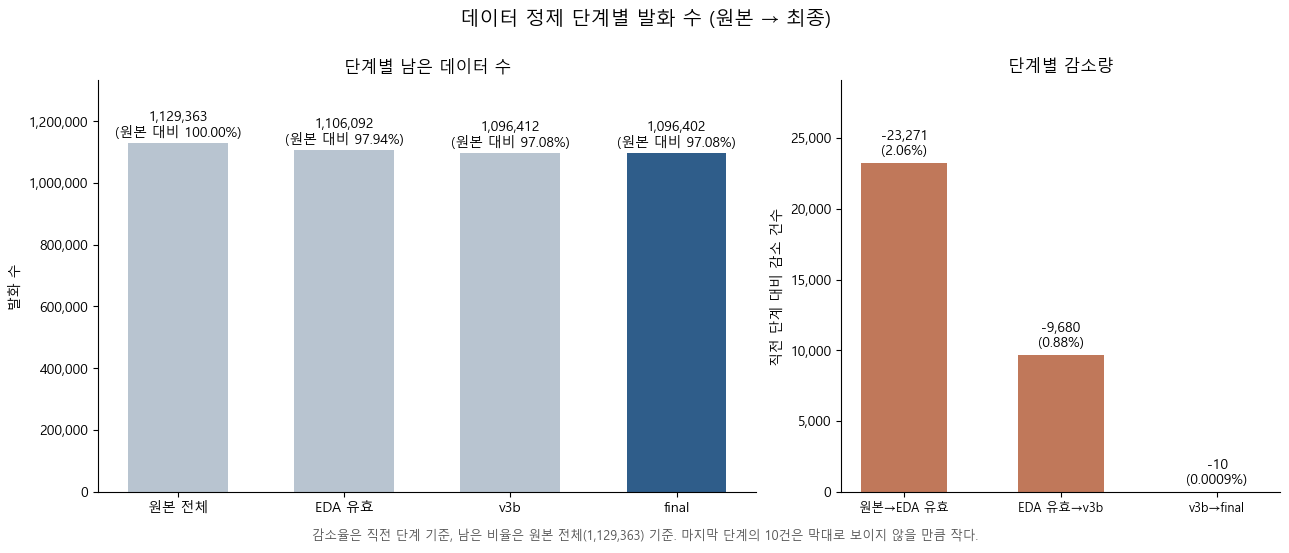

In [18]:
# [요약 셀 2] 정제 단계별 막대그래프
fmt_thousands = FuncFormatter(lambda v, _: f"{int(v):,}")
labels = ["원본 전체", "EDA 유효", "v3b", "final"]
counts = STAGE_DF["개수"].tolist()
keep_pct = STAGE_DF["원본 대비 남은 비율(%)"].tolist()
colors = ["#b8c4d0", "#b8c4d0", "#b8c4d0", "#2f5d8a"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [3, 2]})

bars = ax1.bar(labels, counts, color=colors, width=0.6)
for b, n, p in zip(bars, counts, keep_pct):
    ax1.text(b.get_x() + b.get_width() / 2, n + max(counts) * 0.01, f"{n:,}\n(원본 대비 {fmt_pct(p)}%)",
             ha="center", va="bottom", fontsize=10)
ax1.set_ylim(0, max(counts) * 1.18)          # 0에서 시작 (축을 자르지 않는다)
ax1.yaxis.set_major_formatter(fmt_thousands)
ax1.set_ylabel("발화 수")
ax1.set_title("단계별 남은 데이터 수")

step_names = ["원본→EDA 유효", "EDA 유효→v3b", "v3b→final"]
drops = STAGE_DF["직전 대비 감소"].iloc[1:].astype(int).tolist()
drop_rates = STAGE_DF["직전 대비 감소율(%)"].iloc[1:].tolist()
bars2 = ax2.bar(step_names, drops, color="#c0785a", width=0.55)
for b, d, r in zip(bars2, drops, drop_rates):
    ax2.text(b.get_x() + b.get_width() / 2, d + max(drops) * 0.015, f"-{d:,}\n({fmt_pct(r)}%)",
             ha="center", va="bottom", fontsize=10)
ax2.set_ylim(0, max(drops) * 1.25)
ax2.yaxis.set_major_formatter(fmt_thousands)
ax2.set_ylabel("직전 단계 대비 감소 건수")
ax2.set_title("단계별 감소량")
ax2.tick_params(axis="x", labelsize=9)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("데이터 정제 단계별 발화 수 (원본 → 최종)", fontsize=14, y=1.0)
fig.text(0.5, -0.02, "감소율은 직전 단계 기준, 남은 비율은 원본 전체(1,129,363) 기준. 마지막 단계의 10건은 막대로 보이지 않을 만큼 작다.",
         ha="center", fontsize=9, color="#555555")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_stage_counts.png", dpi=200, bbox_inches="tight")
plt.show()

### 코드 셀 3: 최종 split 표

In [19]:
# [요약 셀 3] 최종 split 구성 표
SPLIT_NAMES = [("Train", "train"), ("Validation", "validation"), ("Test", "test")]
n_rows = {k: len(saved[k]) for _, k in SPLIT_NAMES}
n_docs = {k: int(saved[k]["document_id"].nunique()) for _, k in SPLIT_NAMES}
tot_rows, tot_docs = sum(n_rows.values()), sum(n_docs.values())
assert tot_rows == N_FINAL
assert (n_rows["train"], n_rows["validation"], n_rows["test"]) == (986_718, 54_730, 54_954)

SPLIT_DF = pd.DataFrame([{"split": nm, "발화 수": n_rows[k], "최종 대비 비율(%)": n_rows[k] / tot_rows * 100,
                          "문서 수": n_docs[k], "문서 비율(%)": n_docs[k] / tot_docs * 100} for nm, k in SPLIT_NAMES])
SPLIT_DF.loc[len(SPLIT_DF)] = ["합계", tot_rows, 100.0, tot_docs, 100.0]

view = SPLIT_DF.copy()
view["발화 수"] = view["발화 수"].map(fmt_int)
view["문서 수"] = view["문서 수"].map(fmt_int)
view["최종 대비 비율(%)"] = view["최종 대비 비율(%)"].map(fmt_pct)
view["문서 비율(%)"] = view["문서 비율(%)"].map(fmt_pct)
print("[표 2] 최종 split 구성")
print(view.to_string(index=False))
print("\n※ 90:5:5는 발화(행) 수 기준이다. 문서 단위로 분할했지만 각 문서의 발화 수가 서로 다르기 때문에 문서 수 비율과 발화 수 비율은 일치하지 않는다.")
SPLIT_DF.to_csv(FIG_DIR / "split_counts.csv", index=False, encoding="utf-8-sig")

[표 2] 최종 split 구성
     split      발화 수 최종 대비 비율(%)   문서 수 문서 비율(%)
     Train   986,718       90.00 18,328    85.97
Validation    54,730        4.99  1,527     7.16
      Test    54,954        5.01  1,465     6.87
        합계 1,096,402      100.00 21,320   100.00

※ 90:5:5는 발화(행) 수 기준이다. 문서 단위로 분할했지만 각 문서의 발화 수가 서로 다르기 때문에 문서 수 비율과 발화 수 비율은 일치하지 않는다.


### 코드 셀 4: split 막대그래프

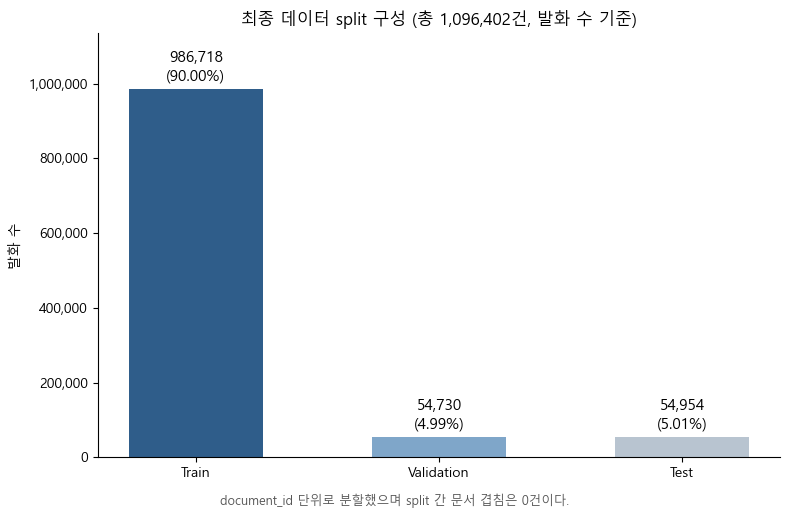

In [20]:
# [요약 셀 4] 최종 split 구성 그래프 (막대)
names = SPLIT_DF["split"].iloc[:3].tolist()
vals = SPLIT_DF["발화 수"].iloc[:3].astype(int).tolist()
pcts = SPLIT_DF["최종 대비 비율(%)"].iloc[:3].tolist()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, vals, color=["#2f5d8a", "#7fa6c9", "#b8c4d0"], width=0.55)
for b, v, p in zip(bars, vals, pcts):
    ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.012, f"{v:,}\n({fmt_pct(p)}%)",
            ha="center", va="bottom", fontsize=11)
ax.set_ylim(0, max(vals) * 1.15)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_ylabel("발화 수")
ax.set_title(f"최종 데이터 split 구성 (총 {sum(vals):,}건, 발화 수 기준)")
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, -0.02, "document_id 단위로 분할했으며 split 간 문서 겹침은 0건이다.", ha="center", fontsize=9, color="#555555")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_split_counts.png", dpi=200, bbox_inches="tight")
plt.show()

### 코드 셀 5: 요약 출력

In [21]:
# [요약 셀 5] 요약 출력
tr, va, te = (SPLIT_DF.loc[i, "최종 대비 비율(%)"] for i in range(3))
print("=" * 78)
print(f" 최종 데이터셋: {DATASET_VERSION}   (생성 {created})")
print("=" * 78)
print(f" 1) 원본 전체 {N_ORIGINAL:,}건 중 {N_FINAL:,}건 유지 (원본 대비 {fmt_pct(N_FINAL / N_ORIGINAL * 100)}%), 제거 {REMOVED_VS_ORIGINAL:,}건 ({fmt_pct(REMOVED_VS_ORIGINAL / N_ORIGINAL * 100)}%)")
print(f" 2) EDA 유효 발화 {N_EDA_VALID:,}건 기준 최종 제거 {REMOVED_VS_VALID:,}건 ({fmt_pct(REMOVED_VS_VALID / N_EDA_VALID * 100)}%)")
print(f" 3) v3b 이후 수동 검증 추가 제거: 표본 판정에서 T로 확인된 {N_MANUAL}건만 (train 한정, v3b 대비 {fmt_pct(N_MANUAL / N_V3B * 100)}%)")
print(f"    - 자동 품질 플래그 행 전체를 삭제하지 않았다. validation/test는 v3b와 파일 해시가 동일하다.")
print(f" 4) 최종 split(발화 수 기준): Train {fmt_pct(tr)}% / Validation {fmt_pct(va)}% / Test {fmt_pct(te)}%")
print(f" 5) 무결성: document_id 겹침 0, utterance_id 중복 0, 빈 input/target 0")
print(f" 6) 동결: FINAL_MANIFEST.json에 파일별 SHA-256 기록 (train {manifest['sha256']['train.jsonl'][:12]}...)")
print(f"    이후 모델 실험에서 이 데이터를 수정하지 않으며, 실험 시작 시 해시를 대조한다.")
print(f" 7) 한계: 일반 품질 플래그는 플래그별 30개 표본, 30개 미만인 일부 플래그(6건, 23건)는 전수 확인했다. 검토 범위 밖의 잠재적 결함은 남아 있을 수 있다.")
print("=" * 78)
print(f"그림/표 저장 위치: {FIG_DIR}")
for p in sorted(FIG_DIR.iterdir()):
    print("  ", p.name)

 최종 데이터셋: preprocessed_final_v1   (생성 2026-09-20T17:28:30+09:00)
 1) 원본 전체 1,129,363건 중 1,096,402건 유지 (원본 대비 97.08%), 제거 32,961건 (2.92%)
 2) EDA 유효 발화 1,106,092건 기준 최종 제거 9,690건 (0.88%)
 3) v3b 이후 수동 검증 추가 제거: 표본 판정에서 T로 확인된 10건만 (train 한정, v3b 대비 0.0009%)
    - 자동 품질 플래그 행 전체를 삭제하지 않았다. validation/test는 v3b와 파일 해시가 동일하다.
 4) 최종 split(발화 수 기준): Train 90.00% / Validation 4.99% / Test 5.01%
 5) 무결성: document_id 겹침 0, utterance_id 중복 0, 빈 input/target 0
 6) 동결: FINAL_MANIFEST.json에 파일별 SHA-256 기록 (train 84181f125239...)
    이후 모델 실험에서 이 데이터를 수정하지 않으며, 실험 시작 시 해시를 대조한다.
 7) 한계: 일반 품질 플래그는 플래그별 30개 표본, 30개 미만인 일부 플래그(6건, 23건)는 전수 확인했다. 검토 범위 밖의 잠재적 결함은 남아 있을 수 있다.
그림/표 저장 위치: C:\Users\KDS-18\Desktop\pro4_team3\output\final_summary
   fig1_stage_counts.png
   fig2_split_counts.png
   split_counts.csv
   stage_counts.csv
